# Tesla Stock Price Forecasting using LSTM

## Importing Necessary Libraries

In [90]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

## Reading the Data

In [91]:
df = pd.read_csv("./Tesla.csv", parse_dates=True, index_col="Date")
df.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [92]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [93]:
print(df.shape)
df.info()

(1692, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1692 entries, 2010-06-29 to 2017-03-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1692 non-null   float64
 1   High       1692 non-null   float64
 2   Low        1692 non-null   float64
 3   Close      1692 non-null   float64
 4   Volume     1692 non-null   int64  
 5   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 92.5 KB


## Data Visualization


<Axes: >

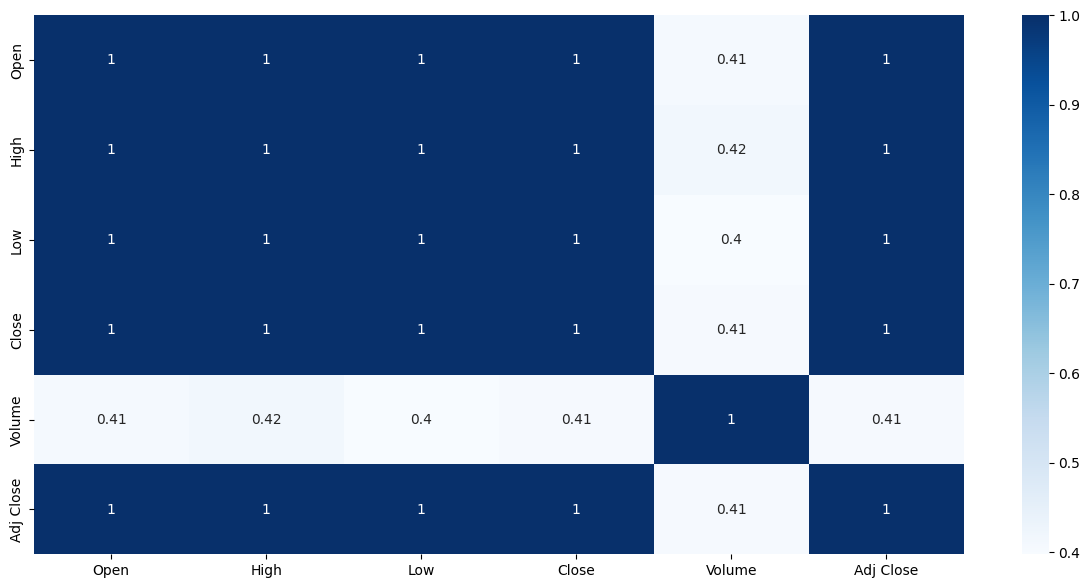

In [94]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(),cbar=True, annot=True, cmap='Blues')

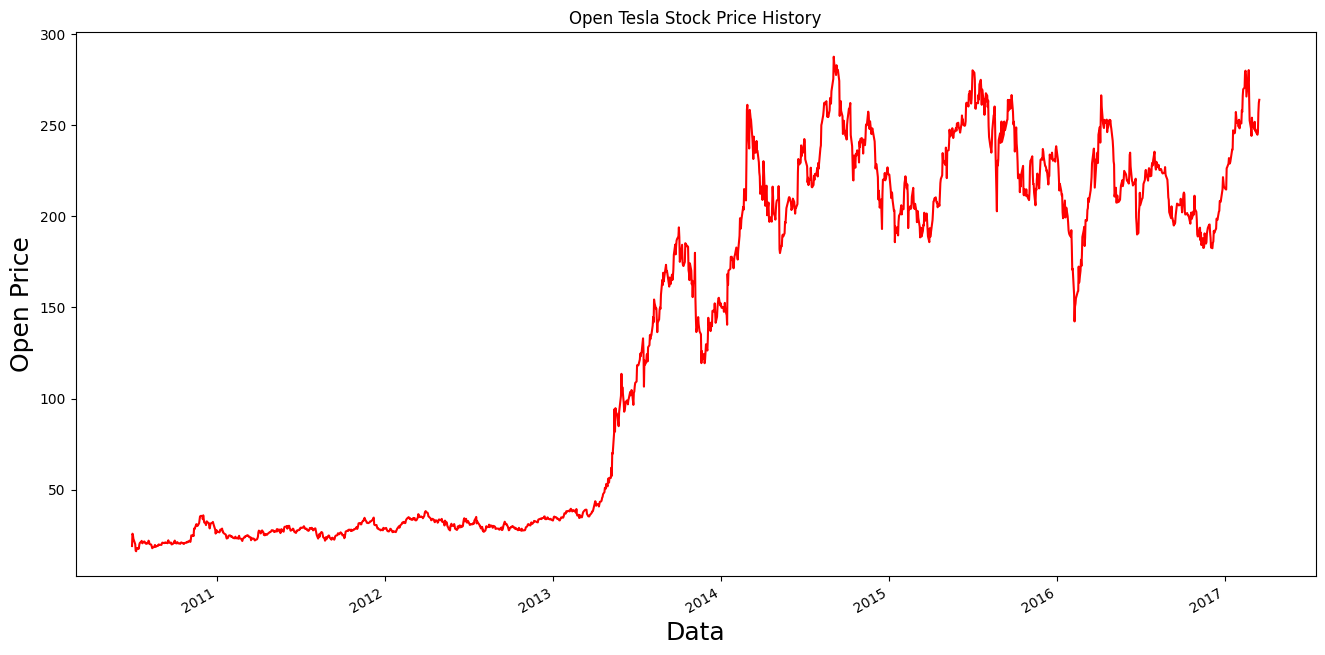

In [95]:
df["Open"].plot(figsize=(16,8), color='red')
plt.title("Open Tesla Stock Price History")
plt.xlabel('Data', fontsize=18)
plt.ylabel('Open Price', fontsize=18)
plt.show()

[ 16.139999  16.4       17.389999 ... 282.98999  284.01001  287.670013] This is the Sorted data of Open Share Price


Text(0, 0.5, 'Frequency')

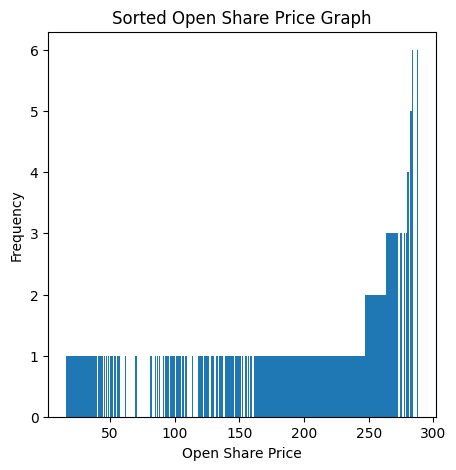

In [96]:
print(np.sort(df['Open']), "This is the Sorted data of Open Share Price")
plt.figure(figsize=(5,5))
plt.bar(list(np.sort(df['Open'].value_counts().keys())), list(np.sort(df['Open'].value_counts())))
plt.title("Sorted Open Share Price Graph")
plt.xlabel("Open Share Price")
plt.ylabel("Frequency")

## Data Preprocessing

In [97]:
df.isna().any()

,0
Open,False
High,False
Low,False
Close,False
Volume,False
Adj Close,False


### Choosing Prediction Column

In [98]:
dataset = df["Open"]
dataset = pd.DataFrame(dataset)

data = dataset.values
data.shape

(1692, 1)

### Normalizing Data

In [99]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

### Splitting the Data

In [100]:
# 75% to Train, 25% to Test

train_size = int (len(data) * 0.75)
test_size = len(data) - train_size

print("Train Size :", train_size,"Test Size :", test_size)

train_data = scaled_data[ :train_size, 0:1]
test_data = scaled_data[ train_size-60: , 0:1]

Train Size : 1269 Test Size : 423


In [101]:
train_data.shape, test_data.shape

((1269, 1), (483, 1))

## Creating training set

In [102]:
# Creating a Training set with 60 time-steps and 1 output

x_train = []
y_train = []

for i in range (60, len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])

In [103]:
# convert to numpy array

x_train, y_train = np.array(x_train), np.array(y_train)

In [104]:
# Reshaping the input

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [105]:
x_train.shape, y_train.shape

((1209, 60, 1), (1209,))

## Building LSTM Model

In [106]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(32))
model.add(Dense(16))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mean_squared_error'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [107]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,465 (165.88 KB)

 Trainable params: 42,465 (165.88 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
# Fitting the LSTM to the Training Set

callbacks = [EarlyStopping(monitor = 'loss', patience = 10, restore_best_weights=True)]
history = model.fit(x_train, y_train, epochs = 100, batch_size = 32, callbacks = callbacks)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0166 - mean_squared_error: 0.0166
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0011 - mean_squared_error: 0.0011
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0010 - mean_squared_error: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 9.8039e-04 - mean_squared_error: 9.8039e-04
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 8.9326e-04 - mean_squared_error: 8.9326e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 8.9090e-04 - mean_squared_error: 8.9090e-04
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 8.0315e-04 - mean_squared_error: 8.0315e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 9.9975e-04 - mean_squared_error: 9.9975e-04
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 7.6620e-04 - mean_squared_error: 7.

## Visualizing Performance

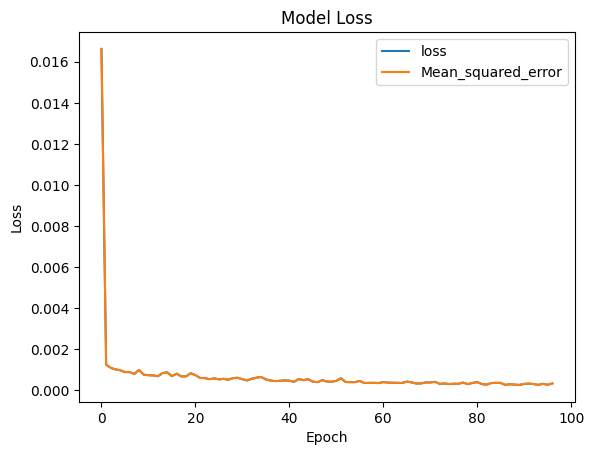

In [109]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_squared_error"])
plt.legend(['loss', 'Mean_squared_error'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

## Creating Testing Set

In [110]:
# Creating a Testing set with 60 time-steps and 1 output

x_test = []
y_test = []

for i in range (60, len(test_data)):
  x_test.append(test_data[i-60:i,0])
  y_test.append(test_data[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

# Reshaping the input

x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [111]:
x_test.shape, y_test.shape

((423, 60, 1), (423,))

## Predicting Testing Data

In [112]:
# inverse y_test scaling

predictions = model.predict(x_test)

# inverse predictions scaling

predictions = scaler.inverse_transform(predictions)
predictions.shape

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


(423, 1)

### Root mean square error

In [113]:
# inverse y_test scaling

y_test = scaler.inverse_transform([y_test])

MSE = mean_squared_error(y_test.T, predictions)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test.T, predictions)

print("MSE :", MSE)
print("RMSE:", RMSE)
print("MAE :", MAE)

MSE : 35.253068473555594
RMSE: 5.93742944998554
MAE : 4.345226256207982


## Visualize Predictions with the Data

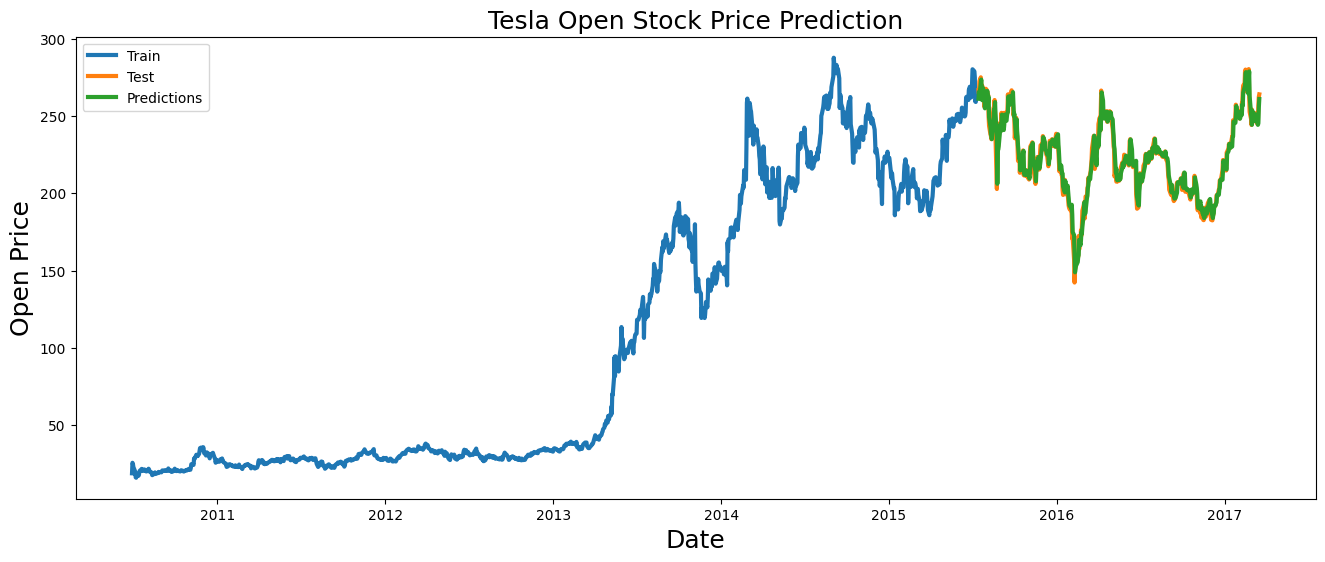

In [114]:
train = dataset.iloc[:train_size , 0:1]
test = dataset.iloc[train_size: , 0:1]
test['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Tesla Open Stock Price Prediction' , fontsize=18)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Open Price' ,fontsize=18)
plt.plot(train['Open'],linewidth=3)
plt.plot(test['Open'],linewidth=3)
plt.plot(test["Predictions"],linewidth=3)
plt.legend(['Train','Test','Predictions'])